# Single Particle Tracking simulator

In [45]:
import helpersGeneration, helpersTracking, helpersStatistics, helpersAssignment
from helpers import *
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
from helpersAssignment import *

In [46]:
%reload_ext autoreload
%autoreload 2

## 1. Particles simulator

Generate frames with moving particles following normal diffusion (Brownian motion)

In [47]:
N = 10 # number of particles
F = 100 # number of frames
frames, trajectories_GT, D_GT = generate_frames_OOP(F, N, amp = 50000, noise_gaussian=True, noise_poisson=True) 

Frame 0
Frame 10
Frame 20
Frame 30
Frame 40
Frame 50
Frame 60
Frame 70
Frame 80
Frame 90


In [48]:
viewer = view_frames(frames)
viewer

## 2. Diffusion coefficients estimation

### 2.0 $ D_{GT} $

In [49]:
print('D_GT =', D_GT)

D_GT = [0, 2, 3, 2, 2, 2, 1, 2, 3, 3]


### 2.1 $ D_{trajectory} $

In [50]:
calculate_msd_trajectories(trajectories_GT)

In [51]:
D_trajectory = estimateDfromTrajectories_safer(trajectories_GT)
print(f"D_trajectory: \n[{', '.join(f'{float(d):.3f}' for d in D_trajectory)}]")

D_trajectory: 
[-0.000, 0.623, 0.497, 0.259, 1.269, 0.935, 0.099, 0.747, 9.593, 2.124]


In [52]:
MAE_trajectory = np.abs(np.array(D_trajectory) - np.array(D_GT))
print(f"MAE for D_trajectory: \n[{', '.join(f'{float(d):.3f}' for d in MAE_trajectory)}]")

MAE for D_trajectory: 
[0.000, 1.377, 2.503, 1.741, 0.731, 1.065, 0.901, 1.253, 6.593, 0.876]


### 2.2 $ D_{detection} $

Detection followed by Local Nearest Neighbor tracking

In [53]:
detected_peaks = detect_peaks(frames)

In [54]:
trajectories_detection = NN_tracking(detected_peaks, max_distance=5)

print("Number of trajectories:", len(trajectories_detection))
print("Sizes of trajectories:", [len(traj.get_positions()) for traj in trajectories_detection])

Number of trajectories: 10
Sizes of trajectories: [100, 100, 100, 10, 100, 100, 13, 29, 100, 100]


### Assignment of detected trajectories to GT trajectories

In [55]:
# assignment using the Hungarian algorithm
trajectories_detection, assignment_detection = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian', verbose=True)

Cost matrix:
[[1.07001878e+02 6.30282118e+01 3.46537442e+01 1.95102060e+01
  3.08547849e+01 8.20764816e+01 9.90476302e+01 7.08328562e+01
  3.62438769e-01 6.72435564e+01]
 [1.24534313e+02 5.44026676e+01 2.21715060e+01 1.89353162e-01
  4.67526716e+01 9.28418476e+01 1.15209843e+02 8.21484745e+01
  1.92052615e+01 8.62779928e+01]
 [1.78068246e+01 1.14855320e+02 1.33662318e+02 1.15257876e+02
  6.85671016e+01 4.23569475e+01 3.98564560e-02 4.43556778e+01
  9.93695763e+01 4.50653392e+01]
 [6.06042926e+01 7.92389340e+01 1.18464613e+02 9.70709284e+01
  5.78451291e+01 4.49610674e+00 4.29313607e+01 1.58447438e+01
  8.67359316e+01 6.51588958e+01]
 [7.81212949e+01 6.48316783e+01 6.51536915e+01 4.66494043e+01
  1.80428816e-01 5.34739397e+01 6.87792643e+01 4.21108104e+01
  3.10384622e+01 4.36729069e+01]
 [6.07745013e+01 7.08568854e+01 1.03360324e+02 8.22588751e+01
  4.20352845e+01 1.13417681e+01 4.45154599e+01 1.38967880e-01
  7.11446467e+01 5.43924195e+01]
 [1.42023162e+02 7.03885615e+01 3.07065154e+0

In [56]:
# comparison with pypi algorithm
# trajectories_detection_pypi, assignment_pypi = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian_pypi')

In [57]:
# compare_assignments(assignment, assignment_pypi)

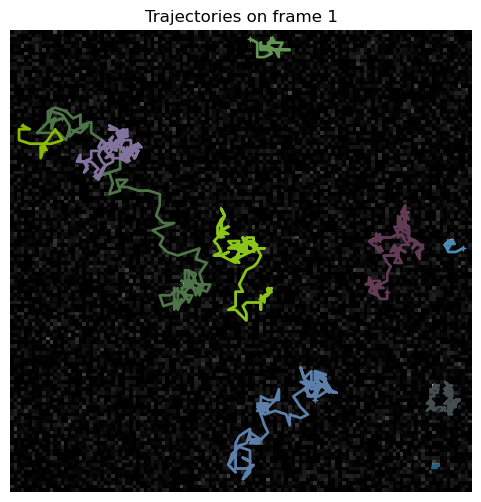

In [58]:
show_trajectories(frames, trajectories_detection, frame_id=0)

In [59]:
calculate_msd_trajectories(trajectories_detection)

In [60]:
D_detection = estimateDfromTrajectories_safer(trajectories_detection)
print(f"D_detection: \n[{', '.join(f'{float(d):.3f}' for d in D_detection)}]")

D_detection: 
[9.945, 0.233, 0.103, 0.470, 1.266, 0.701, 1.811, 0.334, 0.001, 2.144]


In [61]:
# calculate MAE for D_detection
MAE_detection = compute_MAE_detection(trajectories_detection, D_GT)

D_detection:
['0.001', '0.334', '1.811', '0.233', '1.266', '0.470', '0.103', '0.701', '9.945', '2.144']
MAE for D_detection:
['0.001', '1.666', '1.189', '1.767', '0.734', '1.530', '0.897', '1.299', '6.945', '0.856']


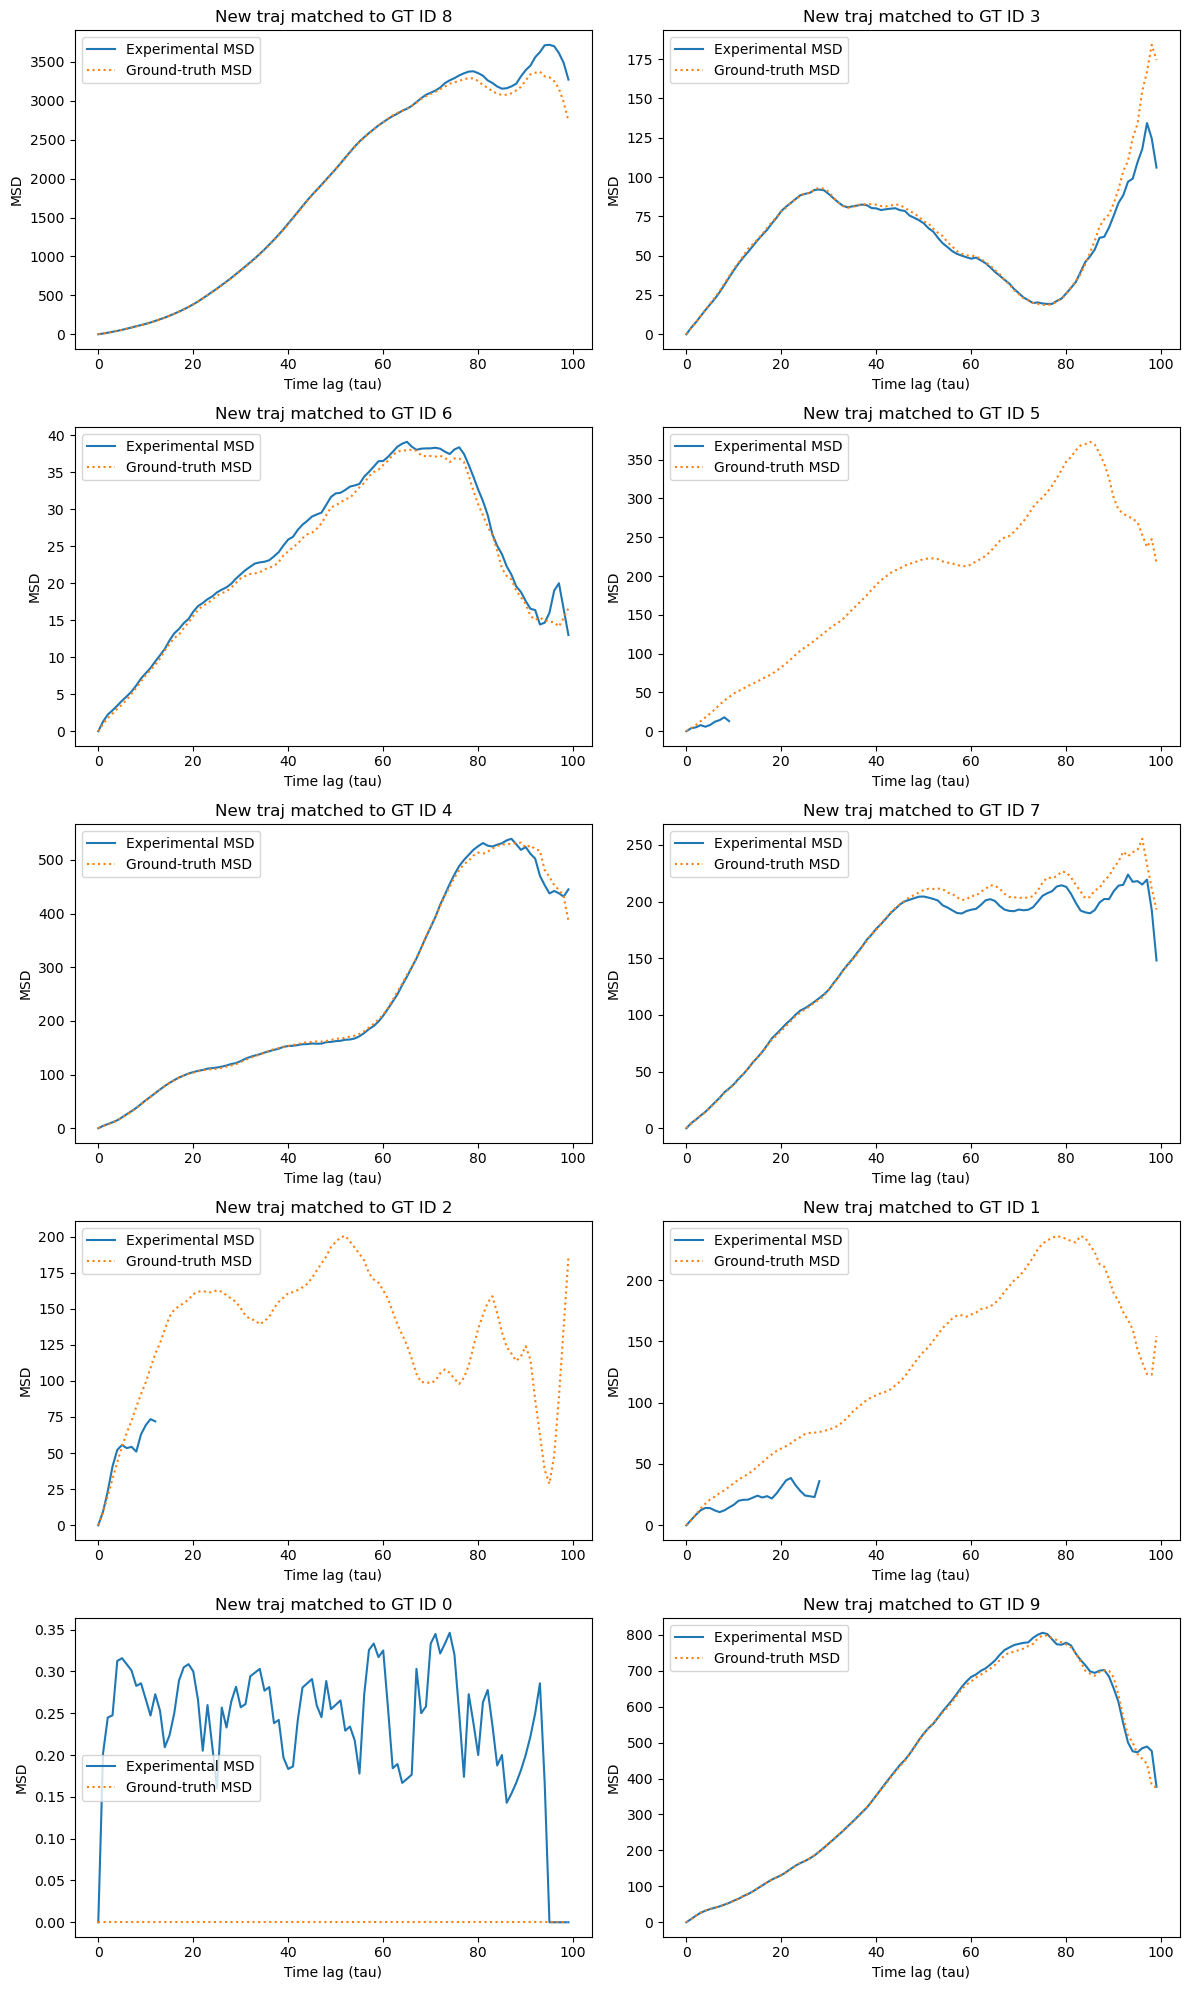

In [80]:
plot_msd_vs_trajectory_msd(trajectories_detection, trajectories_GT)

quick interpretation: one that has GT D 0 but is seen as moving: maybe because its cog landed super close to one moving particle (and the opposite can happen too) 
scale!

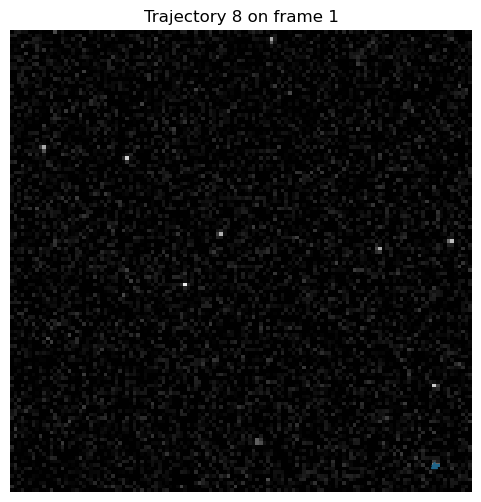

In [63]:
show_trajectory(frames, trajectories_detection, traj_id=8)

### 3.3 $ D_{localization} $

By Gaussian fitting

Fitted center for peak at (70, 48): (70.09, 47.96), amplitude 79290.36, sigma 0.46


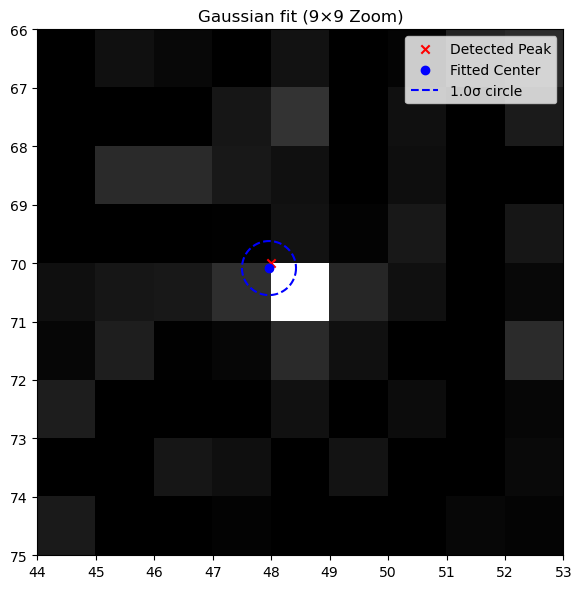

Fitted center for peak at (35, 32): (35.15, 31.90), amplitude 77965.44, sigma 0.47
Fitted center for peak at (98, 117): (98.11, 117.27), amplitude 77166.69, sigma 0.45
Fitted center for peak at (58, 122): (58.09, 121.62), amplitude 89923.93, sigma 0.47
Fitted center for peak at (56, 58): (55.95, 57.80), amplitude 80042.20, sigma 0.52
Fitted center for peak at (60, 102): (60.24, 101.70), amplitude 83892.42, sigma 0.49
Fitted center for peak at (32, 9): (32.33, 8.74), amplitude 77917.56, sigma 0.43
Fitted center for peak at (120, 117): (119.59, 117.47), amplitude 145209.68, sigma 0.30
Fitted center for peak at (113, 68): (113.53, 68.42), amplitude 79916.50, sigma 0.45
Fitted center for peak at (35, 8): (35.04, 7.75), amplitude 76505.18, sigma 0.45
Fitted center for peak at (56, 60): (55.73, 59.78), amplitude 68952.19, sigma 0.43
Fitted center for peak at (33, 33): (33.19, 32.86), amplitude 99889.55, sigma 0.62
Fitted center for peak at (98, 118): (97.53, 118.24), amplitude 79943.48, sigm

In [81]:
# 1min50 rutime for 100 frames
localized_peaks = localize_peaks_with_gaussian_fitting(frames, detected_peaks, verbose=True, visualization=True)

In [82]:
trajectories_localization = NN_tracking(localized_peaks, max_distance=5)

In [83]:
print("Number of localized trajectories:", len(trajectories_localization))

Number of localized trajectories: 9


In [84]:
# assignment using the Hungarian algorithm
trajectories_localization, assignment_localization = assign_trajectories(trajectories_localization, trajectories_GT, algorithm='hungarian', verbose=True)

Cost matrix:
[[3.79094643e+01 1.04406183e+02 1.04339653e+02 8.89131753e+01
  4.38154118e+01 5.37215759e+01 3.63856394e+01 4.72524730e+01
  7.07984848e+01 9.11592443e+00]
 [1.98921371e+01 1.12941275e+02 1.32549802e+02 1.13977291e+02
  6.73646457e+01 4.02482376e+01 2.14646400e+00 4.23551846e+01
  9.82674547e+01 4.52267386e+01]
 [1.35570526e+02 6.27628925e+01 1.03683662e+01 1.24417178e+01
  5.82987154e+01 1.05414144e+02 1.26902072e+02 9.46867688e+01
  2.84058540e+01 9.58918291e+01]
 [6.71439293e+01 7.49257552e+01 7.48391658e+01 5.74635492e+01
  1.14343660e+01 5.01758977e+01 5.89400505e+01 3.92434063e+01
  4.05582285e+01 3.23320549e+01]
 [1.40653714e+02 6.20398437e+01 1.15067458e+01 1.64100676e+01
  6.30944599e+01 1.08938222e+02 1.31640869e+02 9.83870355e+01
  3.37945923e+01 1.01372649e+02]
 [1.23998375e+02 6.29509532e+01 1.81319766e+01 8.54944646e+00
  4.72908790e+01 9.64166003e+01 1.15799592e+02 8.54189931e+01
  1.66417019e+01 8.39556913e+01]
 [5.30191534e+01 7.83059480e+01 1.07233931e+0

In [85]:
calculate_msd_trajectories(trajectories_localization)

In [86]:
print(len(trajectories_localization))

9


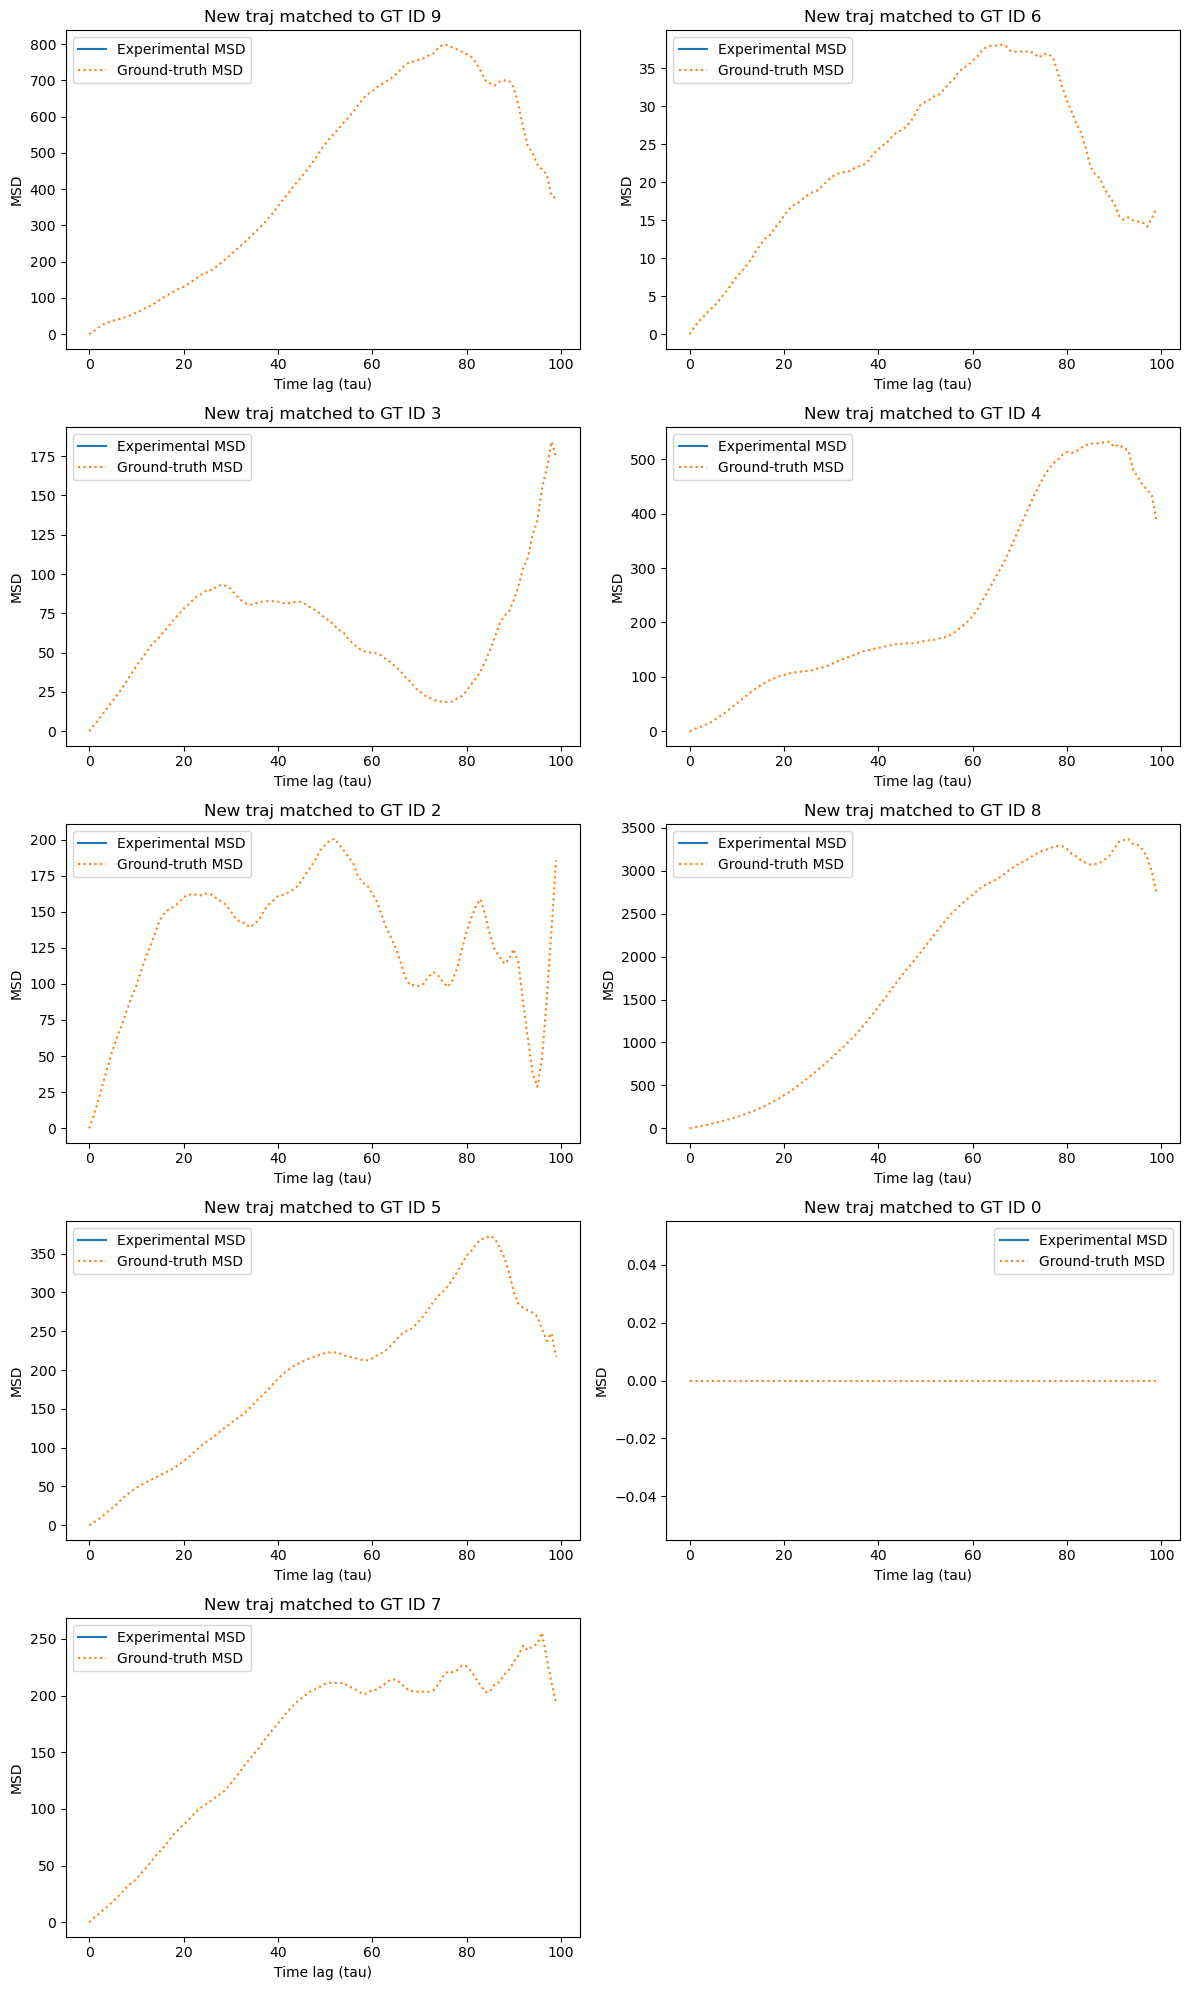

In [87]:
plot_msd_vs_trajectory_msd(trajectories_localization, trajectories_GT)

In [88]:
D_localization = estimateDfromTrajectories(trajectories_localization)
print(f"D_localization: \n[{', '.join(f'{float(d):.3f}' for d in D_localization)}]")

D_localization: 
[0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000]


In [89]:
# calculate MAE for D_localization
MAE = {}
for traj in trajectories_localization:
    MAE[traj.id] = compute_MAE(traj.D_localization, traj.D_trajectory)
print("MAE for D_localization:")
for traj_id, mae in MAE.items():
    if traj_id is not None and traj_id is not -1:
        print(f"{traj_id}: {mae:.3f}")

<>:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?


MAE for D_localization:
9: 0.000
6: 0.000
3: 0.000
4: 0.000
2: 0.000
8: 0.000
5: 0.000
0: 0.000
7: 0.000


C:\Users\armel\AppData\Local\Temp\ipykernel_42056\474422645.py:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if traj_id is not None and traj_id is not -1:


## Extra: Indexing verification

Particle center stored as: (2, 7)
Pixel value at img[row, col]: 1.0


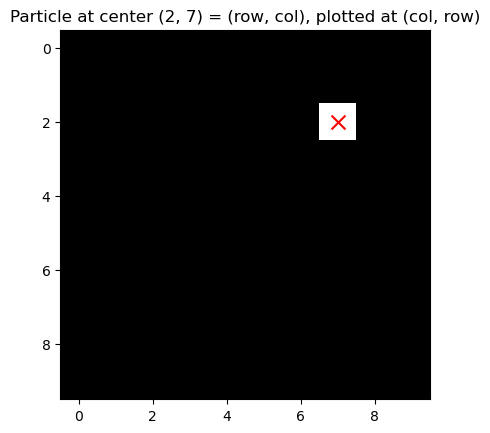

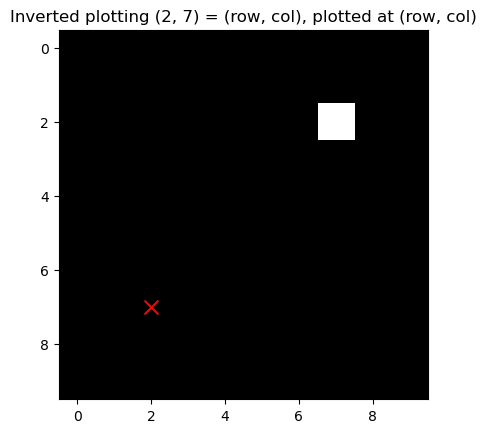

In [90]:
# Create blank image
img = np.zeros((10, 10))

# Put one particle at (row=2, col=7)
p = Particle(ID=1, row_c=2, col_c=7, d=0)

row, col = p.center
img[int(row), int(col)] = 1

print("Particle center stored as:", p.center)
print("Pixel value at img[row, col]:", img[int(row), int(col)])

plt.imshow(img, cmap="gray", interpolation="nearest")
plt.scatter(col, row, c="red", s=100, marker="x")  # plot uses (x, y) = (col, row)
plt.title(f"Particle at center {p.center} = (row, col), plotted at (col, row)")
plt.show()

plt.imshow(img, cmap="gray", interpolation="nearest")
plt.scatter(row, col, c="red", s=100, marker="x") 
plt.title(f"Inverted plotting {p.center} = (row, col), plotted at (row, col)")
plt.show()

=> In conclusion, a particle center can be set at (x, y) = (row, col) and subsequent manipulations can stick to this indexing; it's just for plotting that the convention (col, row) must be used to visualize a particle at what we would call (row, col)